# Imports and opening the files

In [ ]:
#libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import os
import openpyxl
import csv
import sys
import re
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm.notebook import tqdm


In [5]:
csv.field_size_limit(10**7)

# Load in chunks, process each chunk, discard raw text after
results = []
for chunk in pd.read_csv(r"..\data\Newspapers_1.csv", encoding="utf-8", 
                          engine="python", chunksize=500):
    # do your processing here on each chunk, e.g. extract keywords
    results.append(chunk)

news1_df = pd.concat(results, ignore_index=True)

In [6]:
# Load in chunks, process each chunk, discard raw text after
results = []
for chunk in pd.read_csv(r"..\data\Newspapers_2.csv", encoding="utf-8", 
                          engine="python", chunksize=500):
    # do your processing here on each chunk, e.g. extract keywords
    results.append(chunk)

news2_df = pd.concat(results, ignore_index=True)

In [7]:
bonds_df = pd.read_excel(r"..\data\Greece_Germany_Bond_Spread_2010_2026.xlsx")

In [8]:
news1_df.head()

,original_url,final_url,word_count,status,error,date,date_raw,heading_type,article_title,content,extraction_method
0,https://www.capital.gr/diethni/3976815/souidia...,https://www.capital.gr/diethni/3976815/souidia...,148.0,success,NaN,2026-02-26 22:20,"Πέμπτη, 26-Φεβ-2026 22:20",ΔΙΕΘΝΗ,"Drone, πιθανότατα ρωσικό, εντοπίστηκε κοντά στ...",Ένα μη επανδρωμένο αεροσκάφος που εντοπίστηκε ...,readability
1,https://www.capital.gr/diethni/3976810/kouba-o...,https://www.capital.gr/diethni/3976810/kouba-o...,304.0,success,NaN,2026-02-26 21:58,"Πέμπτη, 26-Φεβ-2026 21:58",ΔΙΕΘΝΗ,Ο ένας από τους τέσσερις άνδρες που σκοτώθηκαν...,Ένας από τους τέσσερις άνδρες που σκοτώθηκαν σ...,readability
2,https://www.capital.gr/diethni/3976808/amerika...,https://www.capital.gr/diethni/3976808/amerika...,259.0,success,NaN,2026-02-26 21:39,"Πέμπτη, 26-Φεβ-2026 21:39",ΔΙΕΘΝΗ,Αμερικανοί αξιωματούχοι συναντήθηκαν με τον εγ...,"Αμερικανοί αξιωματούχοι, συνεργάτες του υπουργ...",readability
3,https://www.capital.gr/diethni/3976806/instagr...,https://www.capital.gr/diethni/3976806/instagr...,310.0,success,NaN,2026-02-26 21:28,"Πέμπτη, 26-Φεβ-2026 21:28",ΔΙΕΘΝΗ,Θα ενημερώνει τους γονείς αν το παιδί τους εμφ...,Το Instagram θα προειδοποιεί τους γονείς που έ...,readability
4,https://www.capital.gr/politiki/3976802/k-tsou...,https://www.capital.gr/politiki/3976802/k-tsou...,173.0,success,NaN,2026-02-26 20:58,"Πέμπτη, 26-Φεβ-2026 20:58",ΠΟΛΙΤΙΚΗ,"""Ο κ. Μαρινάκης, πριν ρωτήσει ξανά αν η αντιπο...","Ο εκπρόσωπος Τύπου του ΠΑΣΟΚ-ΚΙΝΑΛ, Κώστας Τσο...",readability


In [9]:
news2_df.head()

,original_url,final_url,word_count,status,error,date,date_raw,heading_type,article_title,content,extraction_method
0,https://www.capital.gr/diethni/3976812/stis-ar...,https://www.capital.gr/diethni/3976812/stis-ar...,143.0,success,NaN,2026-02-26 22:06,"Πέμπτη, 26-Φεβ-2026 22:06",ΔΙΕΘΝΗ,Στις αρχές Μαρτίου στα Εμιράτα η νέα τριμερής ...,Ο επόμενος γύρος των τριμερών ειρηνευτικών δια...,readability
1,https://www.capital.gr/agores/3976809/mikres-m...,https://www.capital.gr/agores/3976809/mikres-m...,282.0,success,NaN,2026-02-26 21:42,"Πέμπτη, 26-Φεβ-2026 21:42",ΑΓΟΡΕΣ,Μικρές μεταβολές ο χρυσός με το βλέμμα στις συ...,Οι τιμές του χρυσού παρέμειναν σχεδόν αμετάβλη...,readability
2,https://www.capital.gr/diethni/3976807/sunanti...,https://www.capital.gr/diethni/3976807/sunanti...,800.0,success,NaN,2026-02-26 21:33,"Πέμπτη, 26-Φεβ-2026 21:33",ΔΙΕΘΝΗ,"Μελόνι: ""Ιταλία και Κύπρος ανήκουν σε έναν...",Ο Κύπριος πρόεδρος Νίκος Χριστοδουλίδης είχε σ...,readability
3,https://www.capital.gr/diethni/3976805/sugkrou...,https://www.capital.gr/diethni/3976805/sugkrou...,224.0,success,NaN,2026-02-26 21:20,"Πέμπτη, 26-Φεβ-2026 21:20",ΔΙΕΘΝΗ,Συγκρούσεις στα σύνορα Πακιστάν - Αφγανιστάν,Οι αρχές των Ταλιμπάν δήλωσαν σήμερα ότι ο αφγ...,readability
4,https://www.capital.gr/diethni/3976801/ipa-ira...,https://www.capital.gr/diethni/3976801/ipa-ira...,220.0,success,NaN,2026-02-26 20:52,"Πέμπτη, 26-Φεβ-2026 20:52",ΔΙΕΘΝΗ,"Ολοκληρώθηκαν οι διαπραγματεύσεις με ""σημαντικ...",Οι διαπραγματεύσεις μεταξύ του Ιράν και των ΗΠ...,readability


In [10]:
bonds_df.head()

,Date,Spread
0,03/01/2026,0.7377
1,02/22/2026,0.6483
2,02/15/2026,0.6095
3,02/08/2026,0.6077
4,02/01/2026,0.6104


# Preprocessing

In [11]:
# Combine both newspaper datasets
df = pd.concat([news1_df, news2_df], ignore_index=True)
# Compute char length
df["char_count"] = df['content'].str.len()

df = df.reset_index(drop=True)
print(f"Total articles: {len(df)}")
df.head()

Total articles: 1566371


,original_url,final_url,word_count,status,error,date,date_raw,heading_type,article_title,content,extraction_method,char_count
0,https://www.capital.gr/diethni/3976815/souidia...,https://www.capital.gr/diethni/3976815/souidia...,148.0,success,NaN,2026-02-26 22:20,"Πέμπτη, 26-Φεβ-2026 22:20",ΔΙΕΘΝΗ,"Drone, πιθανότατα ρωσικό, εντοπίστηκε κοντά στ...",Ένα μη επανδρωμένο αεροσκάφος που εντοπίστηκε ...,readability,1003
1,https://www.capital.gr/diethni/3976810/kouba-o...,https://www.capital.gr/diethni/3976810/kouba-o...,304.0,success,NaN,2026-02-26 21:58,"Πέμπτη, 26-Φεβ-2026 21:58",ΔΙΕΘΝΗ,Ο ένας από τους τέσσερις άνδρες που σκοτώθηκαν...,Ένας από τους τέσσερις άνδρες που σκοτώθηκαν σ...,readability,1978
2,https://www.capital.gr/diethni/3976808/amerika...,https://www.capital.gr/diethni/3976808/amerika...,259.0,success,NaN,2026-02-26 21:39,"Πέμπτη, 26-Φεβ-2026 21:39",ΔΙΕΘΝΗ,Αμερικανοί αξιωματούχοι συναντήθηκαν με τον εγ...,"Αμερικανοί αξιωματούχοι, συνεργάτες του υπουργ...",readability,1800
3,https://www.capital.gr/diethni/3976806/instagr...,https://www.capital.gr/diethni/3976806/instagr...,310.0,success,NaN,2026-02-26 21:28,"Πέμπτη, 26-Φεβ-2026 21:28",ΔΙΕΘΝΗ,Θα ενημερώνει τους γονείς αν το παιδί τους εμφ...,Το Instagram θα προειδοποιεί τους γονείς που έ...,readability,2015
4,https://www.capital.gr/politiki/3976802/k-tsou...,https://www.capital.gr/politiki/3976802/k-tsou...,173.0,success,NaN,2026-02-26 20:58,"Πέμπτη, 26-Φεβ-2026 20:58",ΠΟΛΙΤΙΚΗ,"""Ο κ. Μαρινάκης, πριν ρωτήσει ξανά αν η αντιπο...","Ο εκπρόσωπος Τύπου του ΠΑΣΟΚ-ΚΙΝΑΛ, Κώστας Τσο...",readability,1266


In [12]:
# Check for missing values across all columns
print("=" * 35)
print(f"{'Column':<20} {'NaN Count':>10}")
print("=" * 35)
for col in df.columns:
    print(f"{col:<20} {df[col].isna().sum():>10}")
print("=" * 35)


Column                NaN Count
original_url                  0
final_url                     0
word_count               382862
status                        0
error                   1566371
date                          0
date_raw                 382862
heading_type             369298
article_title                 2
content                       0
extraction_method             0
char_count                    0


In [13]:
# Distribution of status values
print("=" * 35)
print(f"{'Status':<20} {'Count':>10}")
print("=" * 35)
for status, count in df["status"].value_counts().items():
    print(f"{status:<20} {count:>10}")
print("=" * 35)


Status                    Count
success                 1566371


In [14]:
# Distribution of heading types
counts = df["heading_type"].value_counts()
print(f"Total unique heading types: {len(counts)}")
print("=" * 40)
print(f"{'Heading Type':<25} {'Count':>10}")
print("=" * 40)
for heading, count in counts.head(80).items():
    print(f"{heading:<25} {count:>10}")
print("=" * 40)


Total unique heading types: 164
Heading Type                   Count
ΔΙΕΘΝΗ                        230510
ΕΠΙΚΑΙΡΟΤΗΤΑ                  221847
VIDEO_NEWS                    177551
ΟΙΚΟΝΟΜΙΑ                     141472
ΕΠΙΧΕΙΡΗΣΕΙΣ                  113014
ΧΡΗΜ. ΑΝΑΚΟΙΝΩΣΕΙΣ             96891
ΠΟΛΙΤΙΚΗ                       68609
ΑΓΟΡΕΣ                         53309
CAPITALHEALTH                   7201
BRAND VOICE                     5804
ΜΕ ΑΠΟΨΗ                        5782
ΑΡΘΡΑ                           5106
ΠΙΣΩ ΑΠΟ ΤΙΣ ΓΡΑΜΜΕΣ            4906
ΚΩΣΤΑΣ ΣΤΟΥΠΑΣ                  4749
FOREX                           4566
CAPITALTV                       4010
Ο ΓΙΩΡΓΟΣ ΚΡΑΛΟΓΛΟΥ ΓΡΑΦΕΙ       3077
BLOOMBERG OPINION               2967
ΠΑΡΟΥΣΙΑΣΕΙΣ                    2864
ΤΕΧΝΟΛΟΓΙΑ                      2541
ΕΡΕΥΝΕΣ                         2123
REAL ESTATE - ΕΙΔΗΣΕΙΣ          1882
ΕΤΑΙΡΙΚΗ ΚΟΙΝΩΝΙΚΗ ΕΥΘΥΝΗ       1710
CAPITALTECH: INTERNET           1702
Ο ΠΕΤΡΟΣ ΛΑΖΟΣ ΓΡΑΦΕΙ           1650
THINK

In [15]:
df = df.drop(columns=['original_url', 'final_url', 'status', 'error', 'date_raw', 'extraction_method'])

In [16]:
df.head()

,word_count,date,heading_type,article_title,content,char_count
0,148.0,2026-02-26 22:20,ΔΙΕΘΝΗ,"Drone, πιθανότατα ρωσικό, εντοπίστηκε κοντά στ...",Ένα μη επανδρωμένο αεροσκάφος που εντοπίστηκε ...,1003
1,304.0,2026-02-26 21:58,ΔΙΕΘΝΗ,Ο ένας από τους τέσσερις άνδρες που σκοτώθηκαν...,Ένας από τους τέσσερις άνδρες που σκοτώθηκαν σ...,1978
2,259.0,2026-02-26 21:39,ΔΙΕΘΝΗ,Αμερικανοί αξιωματούχοι συναντήθηκαν με τον εγ...,"Αμερικανοί αξιωματούχοι, συνεργάτες του υπουργ...",1800
3,310.0,2026-02-26 21:28,ΔΙΕΘΝΗ,Θα ενημερώνει τους γονείς αν το παιδί τους εμφ...,Το Instagram θα προειδοποιεί τους γονείς που έ...,2015
4,173.0,2026-02-26 20:58,ΠΟΛΙΤΙΚΗ,"""Ο κ. Μαρινάκης, πριν ρωτήσει ξανά αν η αντιπο...","Ο εκπρόσωπος Τύπου του ΠΑΣΟΚ-ΚΙΝΑΛ, Κώστας Τσο...",1266


In [17]:
patterns = df['date'].astype(str).apply(lambda x: re.sub(r'\d', '#', x))
print(patterns.value_counts().to_string())

date
####-##-## ##:##       1183934
####-##-## ##:##:##     334997
####-##-##               47391
##:####/##                  49


In [18]:
for pattern, group in df.groupby(df['date'].astype(str).apply(lambda x: re.sub(r'\d', '#', x))):
    print(f"{pattern}  →  {group['date'].iloc[0]}")

####-##-##  →  2002-05-16
####-##-## ##:##  →  2026-02-26 22:20
####-##-## ##:##:##  →  2004-07-02 15:39:00
##:####/##  →  23:5926/02


In [19]:
# Drop malformed
mask_bad = df['date'].astype(str).str.match(r'^\d{2}:\d{4}/\d{2}')
df = df[~mask_bad].reset_index(drop=True)

# Keep only first 10 chars (YYYY-MM-DD)
df['date'] = df['date'].astype(str).str[:10]

There cannot be a date where tehre is 1 and not 01 because the whole date would be less character and with a check we would catch them, since its zero, tehre isnt a value. 

In [20]:
# Validate date components for hallucinating values
date_parts = df['date'].astype(str).str.extract(r'(\d{2})/(\d{2})/(\d{4})')
date_parts.columns = ['month', 'day', 'year']
date_parts = date_parts.astype(float)

print("Date Component Validation")
print("=" * 40)
print(f"{'Year':<10} min: {date_parts['year'].min():.0f}   max: {date_parts['year'].max():.0f}")
print(f"{'Month':<10} min: {date_parts['month'].min():.0f}   max: {date_parts['month'].max():.0f}   (valid: 1-12)")
print(f"{'Day':<10} min: {date_parts['day'].min():.0f}   max: {date_parts['day'].max():.0f}   (valid: 1-31)")
print("=" * 40)
print(f"{'Month > 12:':<20} {(date_parts['month'] > 12).sum():>10}")
print(f"{'Day > 31:':<20} {(date_parts['day'] > 31).sum():>10}")
print(f"{'Month == 0:':<20} {(date_parts['month'] == 0).sum():>10}")
print(f"{'Day == 0:':<20} {(date_parts['day'] == 0).sum():>10}")
print("=" * 40)


Date Component Validation
Year       min: nan   max: nan
Month      min: nan   max: nan   (valid: 1-12)
Day        min: nan   max: nan   (valid: 1-31)
Month > 12:                   0
Day > 31:                     0
Month == 0:                   0
Day == 0:                     0


In [21]:
# Check for malformed short dates
short = df[df['date'].str.len() < 10]['date']
print("=" * 35)
print(f"{'Dates shorter than 10 chars:':<28} {len(short):>5}")
print("=" * 35)
if len(short) > 0:
    print(f"{'Value':<20} {'Count':>10}")
    print("-" * 35)
    print(short.value_counts().to_string())
print("=" * 35)


Dates shorter than 10 chars:     0


In [22]:
# Convert and validate date format (MM/DD/YYYY)
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d', errors='coerce').dt.strftime('%m/%d/%Y')

print("Date Validation")
print("=" * 30)
print(f"{'NaN / NaT:':<15} {df['date'].isna().sum():>10}")
print(f"{'nan string:':<15} {(df['date'] == 'nan').sum():>10}")
print(f"{'empty string:':<15} {(df['date'] == '').sum():>10}")
print(f"{'len != 10:':<15} {(df['date'].str.len() != 10).sum():>10}")
print("=" * 30)
print(f"\nSample:\n{df['date'].head(5).to_string()}")


Date Validation
NaN / NaT:               0
nan string:              0
empty string:            0
len != 10:               0

Sample:
0    02/26/2026
1    02/26/2026
2    02/26/2026
3    02/26/2026
4    02/26/2026


In [23]:
df.head()

,word_count,date,heading_type,article_title,content,char_count
0,148.0,02/26/2026,ΔΙΕΘΝΗ,"Drone, πιθανότατα ρωσικό, εντοπίστηκε κοντά στ...",Ένα μη επανδρωμένο αεροσκάφος που εντοπίστηκε ...,1003
1,304.0,02/26/2026,ΔΙΕΘΝΗ,Ο ένας από τους τέσσερις άνδρες που σκοτώθηκαν...,Ένας από τους τέσσερις άνδρες που σκοτώθηκαν σ...,1978
2,259.0,02/26/2026,ΔΙΕΘΝΗ,Αμερικανοί αξιωματούχοι συναντήθηκαν με τον εγ...,"Αμερικανοί αξιωματούχοι, συνεργάτες του υπουργ...",1800
3,310.0,02/26/2026,ΔΙΕΘΝΗ,Θα ενημερώνει τους γονείς αν το παιδί τους εμφ...,Το Instagram θα προειδοποιεί τους γονείς που έ...,2015
4,173.0,02/26/2026,ΠΟΛΙΤΙΚΗ,"""Ο κ. Μαρινάκης, πριν ρωτήσει ξανά αν η αντιπο...","Ο εκπρόσωπος Τύπου του ΠΑΣΟΚ-ΚΙΝΑΛ, Κώστας Τσο...",1266


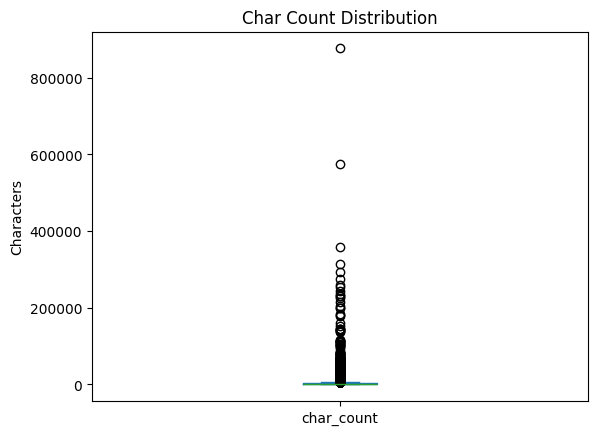

In [24]:
df['char_count'].plot(kind='box', title='Char Count Distribution')
plt.ylabel('Characters')
plt.show()

In [25]:
df["char_count"].describe()

count    1.566322e+06
mean     1.926623e+03
std      2.548777e+03
min      2.500000e+01
25%      5.200000e+02
50%      1.255000e+03
75%      2.573000e+03
max      8.769860e+05
Name: char_count, dtype: float64

In [26]:
# Percentage of articles below each character count threshold
print("=" * 35)
print(f"{'Threshold':<15} {'% of Articles':>15}")
print("=" * 35)
for threshold in [5000, 6000, 7000, 8000, 9000, 10000]:
    pct = (df['char_count'] < threshold).sum() / len(df) * 100
    print(f"< {threshold:>6} chars   {pct:>12.1f}%")
print("=" * 35)


Threshold         % of Articles
<   5000 chars           92.8%
<   6000 chars           95.5%
<   7000 chars           97.0%
<   8000 chars           97.9%
<   9000 chars           98.5%
<  10000 chars           98.9%


In [27]:
# Truncate content to 5000 chars and update char_count
df['content'] = df['content'].str[:5000]
df['char_count'] = df['content'].str.len()

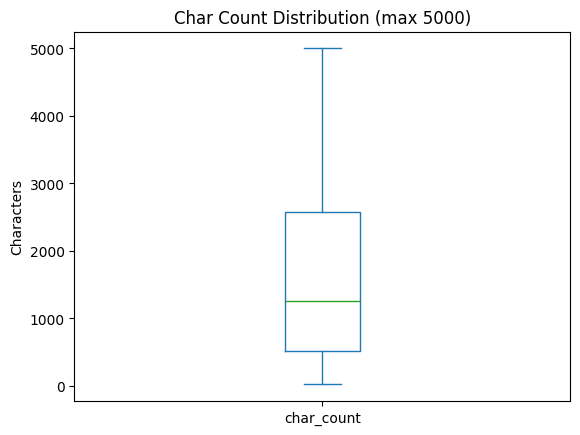

In [28]:
df['char_count'].plot(kind='box', title='Char Count Distribution (max 5000)')
plt.ylabel('Characters')
plt.show()

In [29]:
for cat in df['heading_type'].value_counts().index:
    print(cat)


ΔΙΕΘΝΗ
ΕΠΙΚΑΙΡΟΤΗΤΑ
VIDEO_NEWS
ΟΙΚΟΝΟΜΙΑ
ΕΠΙΧΕΙΡΗΣΕΙΣ
ΧΡΗΜ. ΑΝΑΚΟΙΝΩΣΕΙΣ
ΠΟΛΙΤΙΚΗ
ΑΓΟΡΕΣ
CAPITALHEALTH
BRAND VOICE
ΜΕ ΑΠΟΨΗ
ΑΡΘΡΑ
ΠΙΣΩ ΑΠΟ ΤΙΣ ΓΡΑΜΜΕΣ
ΚΩΣΤΑΣ ΣΤΟΥΠΑΣ
FOREX
CAPITALTV
Ο ΓΙΩΡΓΟΣ ΚΡΑΛΟΓΛΟΥ ΓΡΑΦΕΙ
BLOOMBERG OPINION
ΠΑΡΟΥΣΙΑΣΕΙΣ
ΤΕΧΝΟΛΟΓΙΑ
ΕΡΕΥΝΕΣ
REAL ESTATE - ΕΙΔΗΣΕΙΣ
ΕΤΑΙΡΙΚΗ ΚΟΙΝΩΝΙΚΗ ΕΥΘΥΝΗ
CAPITALTECH: INTERNET
Ο ΠΕΤΡΟΣ ΛΑΖΟΣ ΓΡΑΦΕΙ
THINK TANK
BUSINESSWEEK ONLINE
CAPITALTECH: ΨΥΧΑΓΩΓΙΑ
ENGLISH
Ο ΔΗΜΗΤΡΗΣ ΠΑΠΑΚΩΝΣΤΑΝΤΙΝΟΥ ΓΡΑΦΕΙ
ΑΓΟΡΑ ΑΥΤΟΚΙΝΗΤΟΥ
ΑΝΑΛΥΣΗ
CAPITAL LOGISTIS
ΔΙΑΤΡΟΦΗ
ΣΙΩΠΗΤΗΡΙΟ
Εκλογες Σεπτεμβριος 2015
DELPHI ECONOMIC FORUM
BREXIT
CAPITALTECH: SOFTWARE
IN THE MONEY
ΣΥΝΕΝΤΕΥΞΕΙΣ
ΕΥΕΞΙΑ
ΑΚΙΝΗΤΑ
ΧΡΗΣΤΟΣ ΧΩΜΕΝΙΔΗΣ
ΝΕΕΣ ΘΕΡΑΠΕΙΕΣ
ΦΟΡΟΑΠΟΨΕΙΣ
ΔΗΜΟΤΙΚΕΣ ΕΚΛΟΓΕΣ
ΑΓΩΝΕΣ
EUROBASKET 2017
TRAVEL
ΔΟΚΙΜΕΣ
TAX: ΕΠΙΧΕΙΡ/ΕΛ.ΕΠΑΓΓ.
ΓΑΛΛΙΑ ΕΚΛΟΓΕΣ
PCMAGAZINE: ΑΠΟΨΕΙΣ
ΑΝΤΙΛΟΓΙΕΣ
BLOOMBERG BUSINESSWEEK
RED ALERT
ΟΙΚΟΓΕΝΕΙΑ
FITNESS
Ο ΑΓΗΣ ΒΕΡΟΥΤΗΣ ΓΡΑΦΕΙ
PCMAGAZINE
ΕΚΛΟΓΕΣ ΗΠΑ
TAX: ΦΟΡΟΛΟΓΙΚΕΣ ΔΗΛΩΣΕΙΣ
ΕΚΛΟΓΕΣ ΓΕΡΜΑΝΙΑ
TAX: ΑΝΑΛΥΣΗ - ΕΡΕΥΝΑ
DELPHI ECONOMIC FORUM X
RE: ΑΝΑΛΥΣΕΙΣ


In [30]:
# Drop irrelevant categories (lifestyle, health, sports, entertainment)
trash_categories = [
    'CAPITALHEALTH', 'BRAND VOICE', 'ΔΙΑΤΡΟΦΗ', 'ΕΥΕΞΙΑ', 'ΝΕΕΣ ΘΕΡΑΠΕΙΕΣ', 
    'ΑΓΩΝΕΣ', 'EUROBASKET 2017', 'ΟΙΚΟΓΕΝΕΙΑ', 'FITNESS', 'SEX & ΥΓΕΙΑ', 
    'ASK MAN', 'ΟΛΥΜΠΙΑΚΟΙ ΑΓΩΝΕΣ', 'EKO RALLY ACROPOLIS', 'H ΝΕΑ ΙΑΤΡΙΚΗ 2023', 
    'ΥΓΕΙΑ', 'BRΑND VOICE', 'ΑΠΟΔΡΑΣΕΙΣ', 'AUTO MOTO', 
    'ΟΔΗΓΟΣ ΑΓΟΡΑΣ(ΜΕΤΑΧΕΙΡΙΣΜΕΝΟΥ)', 'ΦΑΚΕΛΟΣ ΥΓΕΙΑΣ', 'ESQUIRE', 'TRAVEL', 'TRAVEL: ΓΕΝΙΚΑ', 'ΑΓΟΡΑ ΑΥΤΟΚΙΝΗΤΟΥ',
]

df = df[~df['heading_type'].isin(trash_categories)].reset_index(drop=True)
print(f"Rows remaining: {len(df)}")


Rows remaining: 1547572


# Embeddings Creation

In [37]:
device = torch.device('cuda')
print(f"Using: {torch.cuda.get_device_name(0)}")

tokenizer = AutoTokenizer.from_pretrained("nlpaueb/bert-base-greek-uncased-v1")
model = AutoModel.from_pretrained("nlpaueb/bert-base-greek-uncased-v1").to(device)
model = model.half()  # add this after loading the model


Using: NVIDIA GeForce GTX 1650


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10017.96it/s]
BertModel LOAD REPORT from: nlpaueb/bert-base-greek-uncased-v1
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [38]:
def get_embeddings_batch(texts, batch_size=32):
    all_embeddings = []
    batches = range(0, len(texts), batch_size)
    for i in tqdm(batches, desc="Generating embeddings", total=len(batches), miniters=1, mininterval=0.1):        
        batch = list(texts[i:i+batch_size])
        inputs = tokenizer(batch, return_tensors="pt", truncation=True,
                           max_length=128, padding=True).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
        all_embeddings.append(embeddings)
    return np.vstack(all_embeddings)

embeddings = get_embeddings_batch(df['content'], batch_size=32)
print(f"Done. Shape: {embeddings.shape}")
np.save('embeddings.npy', embeddings)


Generating embeddings:   0%|          | 34/48362 [01:21<32:13:02,  2.40s/it]


KeyboardInterrupt: 

In [ ]:
#Defined EPU list for later flagging of texts

epu_dict_gr= [
    "EPUM": ["επιτόκιο", "euribor", "κόστος χρήματος", "νομισματική πολιτική", "ποσοτική χαλάρωση"],
    "EPUT": ["φορολογία", "φόρος", "φ.π.α.", "ειδικός φόρος κατανάλωσης", "τακτικά έσοδα", "δημόσια έσοδα", "έσοδα προϋπολογισμού", "έσοδα αποκρατικοποιήσεων", "εφορία"],
    "EPUD": ["δημόσιες δαπάνες", "δαπάνες δημοσίου", "κρατικές δαπάνες", "δαπάνη γενικής κυβέρνησης", "πρωτογενής δαπάνη", "εξοπλιστική δαπάνη", "δημόσια επένδυση", "προϋπολογισμός", "κρατικό χρέος", "δημόσιο χρέος", "οφειλές δημοσίου", "μεταβιβαστικές πληρωμές", "δημόσια κατανάλωση", "επιχορήγηση", "επίδομα", "πτώχευση της χώρας", "πτώχευση της Ελλάδας", "χρεοκοπίας της χώρας", "χρεοκοπία της Ελλάδας"],
    "EPUC": ["συναλλαγματική ισοτιμία", "ισοτιμία του ευρώ", "δραχμή", "ζώνη του ευρώ", "ευρωζώνη", "ανατίμηση", "υποτίμηση", "εθνικό νόμισμα", "οικονομική νομισματική ένωση", "grexit", "έξοδος από το ευρώ"],
    "EPUB": ["τράπεζα", "τραπεζικό σύστημα", "τραπεζικός κλάδος", "τραπεζικός τομέας", "δάνειο", "καταθέσεις", "διατραπεζική αγορά", "επιτόκιο χορηγήσεων", "επιτόκιο καταθέσεων"],
    "EPUP": ["σύνταξη", "εφάπαξ", "ασφαλιστικό σύστημα", "το ασφαλιστικό", "ασφαλιστικό ταμείο", "ίδρυμα κοινωνικών ασφαλίσεων", "κοινωνική ασφάλιση", "ρήτρα μηδενικού ελλείμματος", "ασφαλιστική μεταρρύθμιση", "ασφαλιστική εισφορά", "κεφαλαιοποιητικό σύστημα", "διανεμητικό σύστημα"]
]
epu_dict_en = [
    "EPUM": ["interest rate", "euribor", "cost of money", "monetary policy", "quantitative easing"],
    "EPUT": ["taxation", "tax", "v.a.t.", "value added tax", "excise duty", "regular revenues", "public revenues", "budget revenues", "privatization revenues", "tax authority", "tax office"],
    "EPUD": ["public spending", "government expenditure", "state expenditures", "general government expenditure", "primary expenditure", "defense spending", "public investment", "budget", "state debt", "public debt", "government liabilities", "transfer payments", "public consumption", "grant", "subsidy", "allowance", "country bankruptcy", "bankruptcy of Greece", "country default", "greek default", "default of Greece"],
    "EPUC": ["exchange rate", "euro exchange rate", "drachma", "euro area", "eurozone", "revaluation", "appreciation", "devaluation", "depreciation", "national currency", "economic and monetary union", "grexit", "euro exit"],
    "EPUB": ["bank", "banking system", "banking sector", "banking industry", "loan", "deposits", "interbank market", "lending rate", "deposit rate"],
    "EPUP": ["pension", "lump sum", "social security system", "pension system", "social security fund", "pension fund", "social insurance institute", "social security", "zero deficit clause", "pension reform", "social security contribution", "funded system", "pay-as-you-go system"]
]
